In [433]:
#Bloc d'importation des librairies
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# --- Sommets d'un cube 3D (8 points) ---
points = np.array([
    [0, 0, 3],
    [1, 0, 3],
    [1, 1, 3],
    [0, 1, 3],
    [0, 0, 4],
    [1, 0, 4],
    [1, 1, 4],
    [0, 1, 4]
])


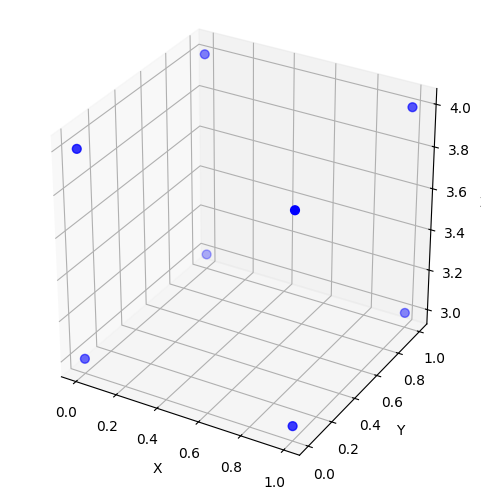

In [435]:

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], color='blue', s=40)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1,1,1])
plt.show()


PointRepereScene = np.array([0, 0, 0])

In [436]:
#Définition des paramètres de la caméra et de la scène parametres extrinsceques

CameraOrientation = np.array([0,0,0])
CameraPosition = np.array([0,0,0])


#Le prof ayant donné la matrice K je la definis directement 
alpha_u = 700
alpha_v = 700
u_0 = 400
v_0 = 300

CameraIntrinsicsMatrix = np.array([[alpha_u, 0, u_0], [0, alpha_v, v_0], [0, 0, 1]])

In [437]:
alpha = CameraOrientation[0]
beta = CameraOrientation[1]
gamma = CameraOrientation[2]

def EulerRotationMatrix(alpha, beta, gamma):

    EulerRotationMatrix_X = np.array([ [1,0,0], [0, np.cos(alpha), -np.sin(alpha)], [0, np.sin(alpha), np.cos(alpha)] ])

    EulerRotationMatrix_Y = np.array([ [np.cos(beta), 0, np.sin(beta)], [0,1,0], [-np.sin(beta), 0, np.cos(beta)] ])

    EulerRotationMatrix_Z = np.array([ [np.cos(gamma), -np.sin(gamma), 0], [np.sin(gamma), np.cos(gamma), 0], [0,0,1] ])

    EulerRotationMatrix = np.dot(EulerRotationMatrix_Z, np.dot(EulerRotationMatrix_Y, EulerRotationMatrix_X))

    return EulerRotationMatrix

EulerRotationMatrix = EulerRotationMatrix(alpha, beta, gamma)
EulerRotationMatrix

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [438]:
Pseudo_TranslationMatrix = - np.dot(EulerRotationMatrix,CameraPosition)
Pseudo_TranslationMatrix

array([-0., -0., -0.])

In [439]:
# Concaténer la matrice de rotation et la translation pour obtenir une matrice 3x4
rotation_translation = np.hstack((EulerRotationMatrix, Pseudo_TranslationMatrix.reshape(3,1)))
#print(rotation_translation)
# Ajouter la dernière ligne pour obtenir une matrice 4x4 homogène
CameraProjectionMatrix = np.vstack((rotation_translation, np.array([[0, 0, 0, 1]])))
CameraProjectionMatrix

array([[ 1.,  0.,  0., -0.],
       [ 0.,  1.,  0., -0.],
       [ 0.,  0.,  1., -0.],
       [ 0.,  0.,  0.,  1.]])

In [440]:
Poin_cam_repere = []
for vec in points:
    print(vec)
    vec = np.hstack((vec, 1))
    print(vec)
    Rot_trans_dot_point_scene = np.dot(CameraProjectionMatrix, vec)
    Poin_cam_repere.append(Rot_trans_dot_point_scene)
Poin_cam_repere = np.array(Poin_cam_repere)
Poin_cam_repere

[0 0 3]
[0 0 3 1]
[1 0 3]
[1 0 3 1]
[1 1 3]
[1 1 3 1]
[0 1 3]
[0 1 3 1]
[0 0 4]
[0 0 4 1]
[1 0 4]
[1 0 4 1]
[1 1 4]
[1 1 4 1]
[0 1 4]
[0 1 4 1]


array([[0., 0., 3., 1.],
       [1., 0., 3., 1.],
       [1., 1., 3., 1.],
       [0., 1., 3., 1.],
       [0., 0., 4., 1.],
       [1., 0., 4., 1.],
       [1., 1., 4., 1.],
       [0., 1., 4., 1.]])

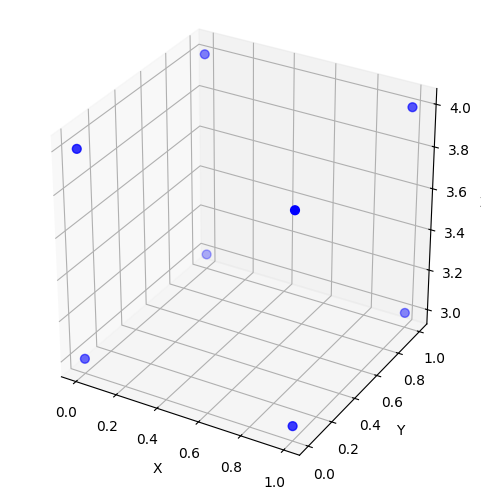

In [441]:

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Poin_cam_repere[:,0], Poin_cam_repere[:,1], Poin_cam_repere[:,2], color='blue', s=40)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1,1,1])
plt.show()

In [442]:
#Projection

Poin_cam_repere = Poin_cam_repere[:,0:3]
print(Poin_cam_repere)
print(Poin_cam_repere[:,0:2],Poin_cam_repere[:,2])
Poin_projection = Poin_cam_repere[:,0:2] / Poin_cam_repere[:,2][:, np.newaxis]


print(Poin_projection)

[[0. 0. 3.]
 [1. 0. 3.]
 [1. 1. 3.]
 [0. 1. 3.]
 [0. 0. 4.]
 [1. 0. 4.]
 [1. 1. 4.]
 [0. 1. 4.]]
[[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]
 [0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]] [3. 3. 3. 3. 4. 4. 4. 4.]
[[0.         0.        ]
 [0.33333333 0.        ]
 [0.33333333 0.33333333]
 [0.         0.33333333]
 [0.         0.        ]
 [0.25       0.        ]
 [0.25       0.25      ]
 [0.         0.25      ]]


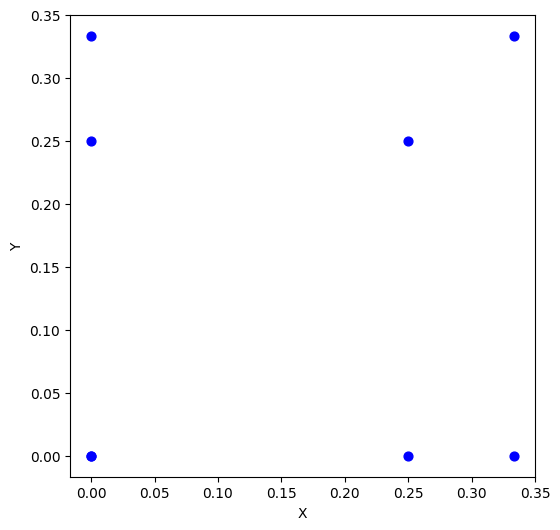

In [443]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.scatter(Poin_projection[:,0], Poin_projection[:,1], color='blue', s=40)

ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

In [444]:
Poin_Projected = []
for vec in Poin_projection:
    vec = np.hstack((vec, 1))
    Poin_pixel = np.dot(CameraIntrinsicsMatrix, vec)
    Poin_Projected.append(Poin_pixel)

Poin_Projected = np.array(Poin_Projected)[:,:2]
Poin_Projected

array([[400.        , 300.        ],
       [633.33333333, 300.        ],
       [633.33333333, 533.33333333],
       [400.        , 533.33333333],
       [400.        , 300.        ],
       [575.        , 300.        ],
       [575.        , 475.        ],
       [400.        , 475.        ]])

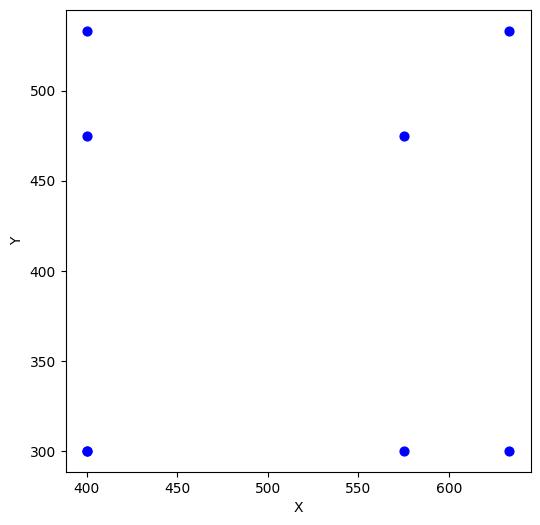

In [445]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)
ax.scatter(Poin_Projected[:,0], Poin_Projected[:,1], color='blue', s=40)

ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

In [446]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Fonction de quantification
def quantize(img, levels):
    # taille d'un "palier"
    step = 256 // levels
    # division -> arrondi -> re-multiplication
    quantized = (img // step) * step
    return quantized.astype(np.uint8)

def show_img(img, position, total, level, cmap="gray"):
    """
    Affiche une image dans une grille de subplots.

    Parameters
    ----------
    img : array
        L'image à afficher.
    position : int
        La position dans la grille (1 = premier subplot).
    total : int
        Le nombre total d'images dans la grille.
    level : int
        Le nombre de niveaux (pour le titre).
    cmap : str
        La colormap (par défaut = "gray").
    """
    cols = int(np.ceil(np.sqrt(total)))   # nombre de colonnes
    rows = int(np.ceil(total / cols))     # nombre de lignes
    plt.subplot(rows, cols, position)
    plt.imshow(img, cmap=cmap)
    plt.title(f"Image ({level} niveaux)")
    plt.axis("off")   # pas d'axes visibles


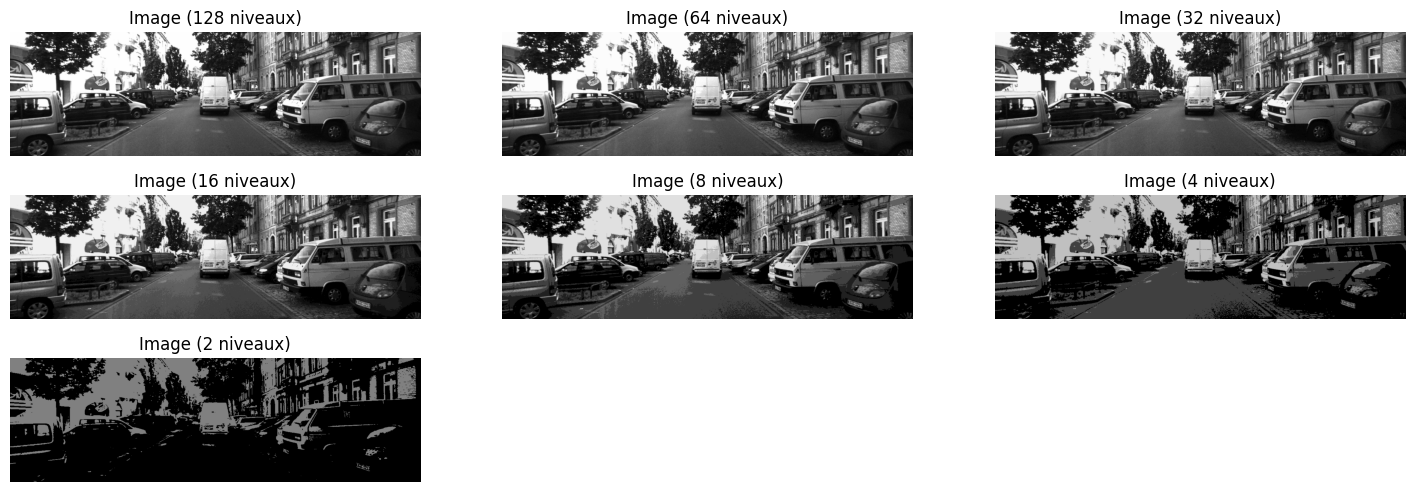

In [447]:
levels = [128, 64, 32, 16, 8, 4, 2]
img = cv.imread("A25_VA51_TP1/ressources/grayscale_img.png")
sub_n = 1

plt.figure(figsize=(18,6))

for level in levels:
    img_val = quantize(img, level)
    show_img(img_val, sub_n, len(levels), level)  # <-- ici on met bien sub_n = position
    sub_n += 1

plt.show()


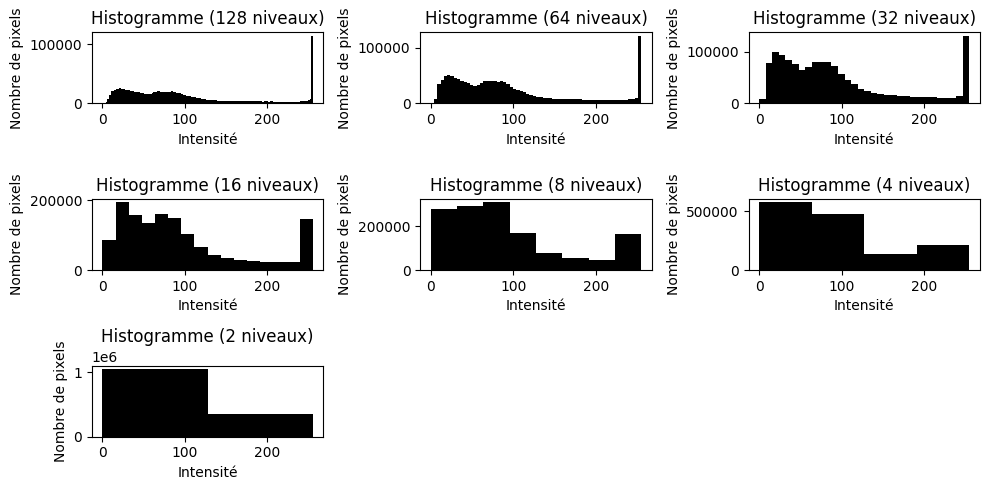

In [448]:
def show_hist(img, position, total, level):
    cols = int(np.ceil(np.sqrt(total)))
    rows = int(np.ceil(total / cols))
    # Affichage de l'histogramme
    plt.subplot(rows, cols, position)
    plt.hist(img.ravel(), bins=level, range=(0,255), color="black")
    plt.title(f"Histogramme ({level} niveaux)")
    plt.xlabel("Intensité")
    plt.ylabel("Nombre de pixels")


plt.figure(figsize=(10,5))

for idx, level in enumerate(levels, start=1):   # idx = 1,2,3,...
    img_val = quantize(img, level)
    show_hist(img_val, idx, len(levels), level)

plt.tight_layout()
plt.show()


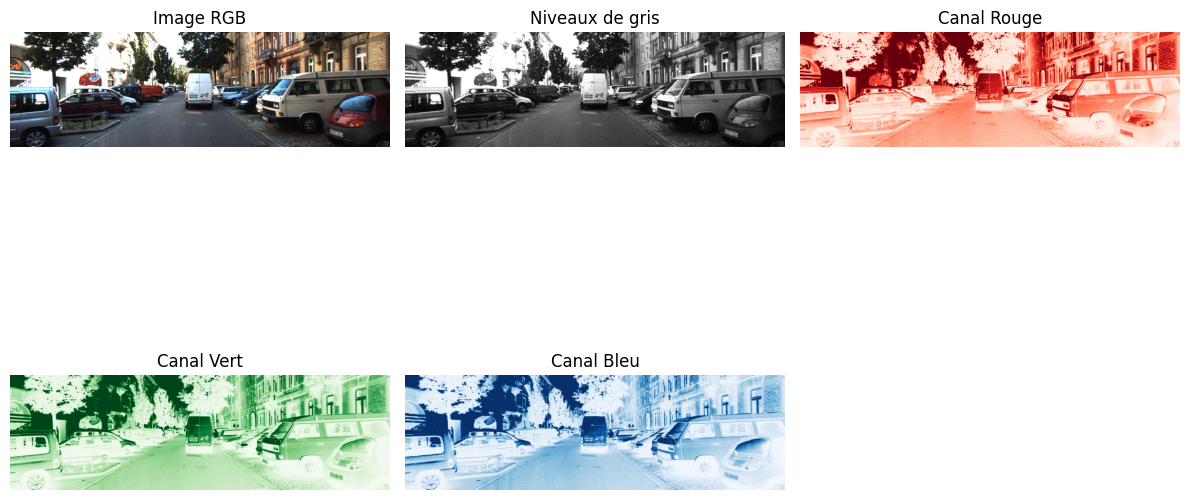

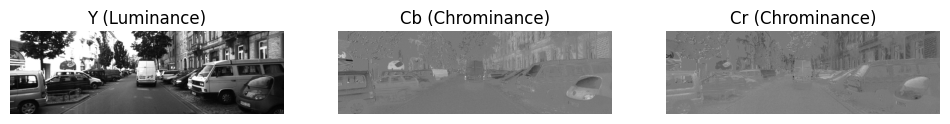

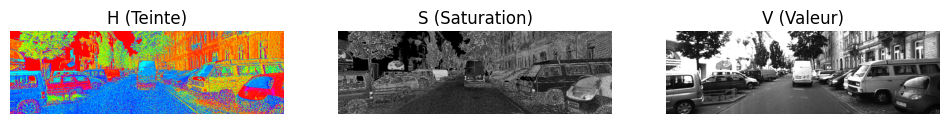

In [449]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- Charger l'image couleur ---
img = cv.imread("A25_VA51_TP1/ressources/rgb_img.png")   # lecture en BGR
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)             # conversion en RGB pour matplotlib

# --- Conversion en niveaux de gris ---
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# --- Séparation des canaux RGB ---
R, G, B = cv.split(img_rgb)

# --- Conversion en YCbCr ---
img_ycbcr = cv.cvtColor(img_rgb, cv.COLOR_RGB2YCrCb)
Y, Cb, Cr = cv.split(img_ycbcr)

# --- Conversion en HSV ---
img_hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)
H, S, V = cv.split(img_hsv)

# --- Affichage RGB ---
plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(img_rgb); plt.title("Image RGB"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(img_gray, cmap="gray"); plt.title("Niveaux de gris"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(R, cmap="Reds"); plt.title("Canal Rouge"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(G, cmap="Greens"); plt.title("Canal Vert"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(B, cmap="Blues"); plt.title("Canal Bleu"); plt.axis("off")
plt.tight_layout(); plt.show()

# --- Affichage YCbCr ---
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(Y, cmap="gray"); plt.title("Y (Luminance)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(Cb, cmap="gray"); plt.title("Cb (Chrominance)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(Cr, cmap="gray"); plt.title("Cr (Chrominance)"); plt.axis("off")
plt.show()

# --- Affichage HSV ---
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(H, cmap="hsv"); plt.title("H (Teinte)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(S, cmap="gray"); plt.title("S (Saturation)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(V, cmap="gray"); plt.title("V (Valeur)"); plt.axis("off")
plt.show()


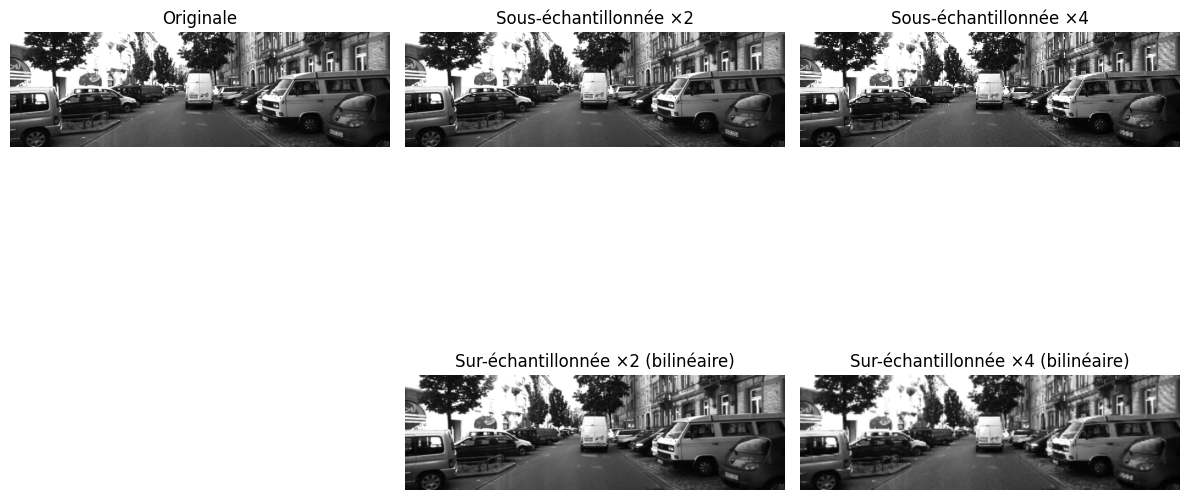

In [450]:
# --- Charger l'image en niveaux de gris ---
img_gray = cv.imread("A25_VA51_TP1/ressources/grayscale_img.png", cv.IMREAD_GRAYSCALE)

# --- Sous-échantillonnage ---
img_sub2 = img_gray[::2, ::2]   # facteur 2
img_sub4 = img_gray[::4, ::4]   # facteur 4

# --- Sur-échantillonnage (interpolation bilinéaire) ---
img_sub2_up = cv.resize(img_sub2, (img_gray.shape[1], img_gray.shape[0]), interpolation=cv.INTER_LINEAR)
img_sub4_up = cv.resize(img_sub4, (img_gray.shape[1], img_gray.shape[0]), interpolation=cv.INTER_LINEAR)

# --- Affichage ---
plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(img_gray, cmap="gray"); plt.title("Originale"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(img_sub2, cmap="gray"); plt.title("Sous-échantillonnée ×2"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(img_sub4, cmap="gray"); plt.title("Sous-échantillonnée ×4"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(img_sub2_up, cmap="gray"); plt.title("Sur-échantillonnée ×2 (bilinéaire)"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(img_sub4_up, cmap="gray"); plt.title("Sur-échantillonnée ×4 (bilinéaire)"); plt.axis("off")
plt.tight_layout(); plt.show()
